# Alpha Shapes: Geometry and Topology Across Scales

Point clouds are discrete samples of continuous objects, and reconstruction requires a scale parameter. Alpha shapes provide a principled multi-scale family between isolated points and the convex hull.

The central stakes are:
- Geometric reconstruction from sparse/noisy samples.
- Control of non-convexity and hole preservation.
- A bridge between computational geometry and topological descriptors.

Using the Delaunay triangulation, we keep simplices whose circumradius is below a threshold:
$$
R_\sigma\le \alpha.
$$
Boundary edges are those incident to exactly one retained triangle.

## Environment

We use planar Delaunay triangulation and interactive sliders for the scale parameter $\alpha$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection, LineCollection
from scipy.spatial import Delaunay
from ipywidgets import interact, FloatLogSlider

plt.rcParams['figure.dpi'] = 120
rng = np.random.default_rng(7)

## Point cloud construction

We synthesize a non-convex cloud so that alpha filtering has visible geometric transitions.

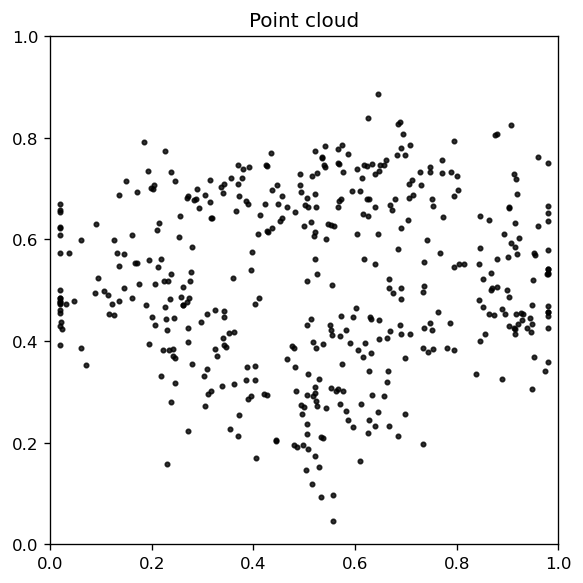

In [2]:
def make_cloud(n=450, noise=0.018):
    t = rng.uniform(0, 2 * np.pi, n)
    r = 0.35 + 0.12 * rng.standard_normal(n)
    x = 0.52 + (0.95 + 0.30 * np.cos(2 * t)) * r * np.cos(t)
    y = 0.52 + (0.65 + 0.15 * np.sin(3 * t)) * r * np.sin(t)
    pts = np.c_[x, y] + noise * rng.standard_normal((n, 2))
    return np.clip(pts, 0.02, 0.98)

points = make_cloud()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(points[:, 0], points[:, 1], s=7, color='black', alpha=0.8)
ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Point cloud')
plt.show()

## Delaunay scaffold and circumradii

For each triangle $(i,j,k)$, the circumradius satisfies
$$
R=\frac{abc}{4\Delta},
$$
with side lengths $(a,b,c)$ and area $\Delta$.

In [3]:
tri = Delaunay(points)
simplices = tri.simplices

A = points[simplices[:, 0]]
B = points[simplices[:, 1]]
C = points[simplices[:, 2]]
a = np.linalg.norm(B - C, axis=1)
b = np.linalg.norm(C - A, axis=1)
c = np.linalg.norm(A - B, axis=1)
s = 0.5 * (a + b + c)
area = np.sqrt(np.clip(s * (s - a) * (s - b) * (s - c), 1e-15, None))
R = (a * b * c) / (4.0 * area)

print('Delaunay triangles:', len(simplices))
print('Circumradius range:', float(R.min()), float(R.max()))

Delaunay triangles: 858
Circumradius range: 0.0018689536787539322 0.9520809293923597


## Alpha complex extraction and Euler characteristic

We keep triangles with $R\le\alpha$, detect boundary edges, and monitor
$$
\chi = V-E+F.
$$

In [4]:
def alpha_shape_geometry(points, simplices, radii, alpha):
    keep = radii <= alpha
    kept = simplices[keep]
    edge_count = {}
    for t in kept:
        for i, j in [(t[0], t[1]), (t[1], t[2]), (t[2], t[0])]:
            key = tuple(sorted((int(i), int(j))))
            edge_count[key] = edge_count.get(key, 0) + 1
    boundary = [k for k, v in edge_count.items() if v == 1]
    interior = [k for k, v in edge_count.items() if v == 2]
    return kept, boundary, interior

def euler_stats(points, simplices, radii, alpha):
    kept, boundary, interior = alpha_shape_geometry(points, simplices, radii, alpha)
    if len(kept) == 0:
        return {'V': 0, 'E': 0, 'F': 0, 'chi': 0}
    verts = np.unique(kept.ravel())
    edges = len(boundary) + len(interior)
    faces = len(kept)
    chi = len(verts) - edges + faces
    return {'V': len(verts), 'E': edges, 'F': faces, 'chi': chi}

## Interactive alpha exploration

The slider changes $\alpha$ on a logarithmic scale and updates geometry/topology statistics.

## Multi-scale snapshots

A compact panel for visual comparison across representative alpha values.

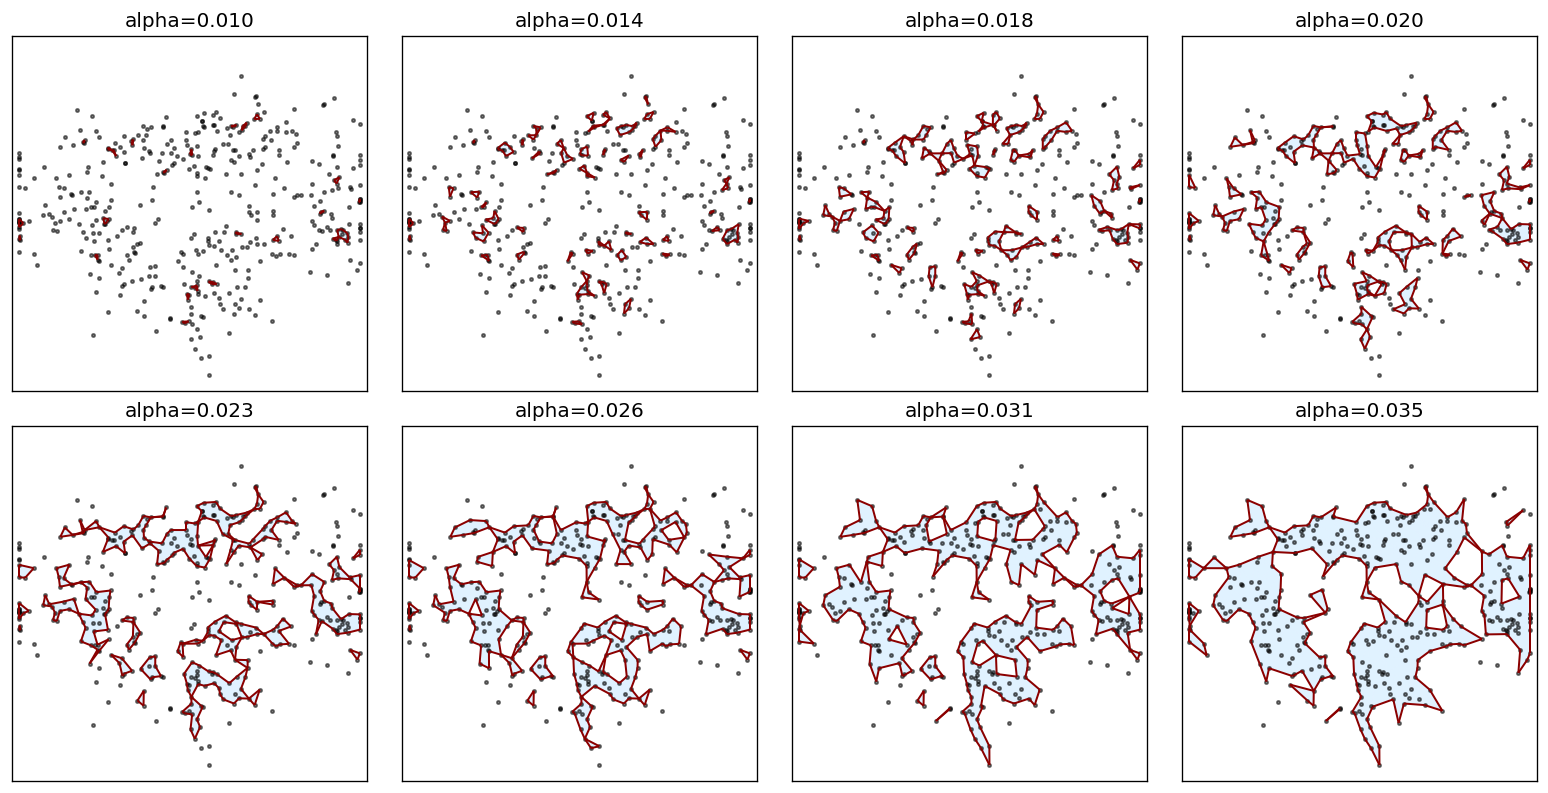

In [5]:
alphas = np.quantile(R, np.linspace(0.05, 0.75, 8))
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5), constrained_layout=True)
for ax, alpha in zip(axes.flat, alphas):
    kept, boundary, _ = alpha_shape_geometry(points, simplices, R, alpha)
    if len(kept) > 0:
        ax.add_collection(PolyCollection([points[t] for t in kept], facecolor=(0.4, 0.75, 1.0, 0.20), edgecolor='none'))
    if boundary:
        ax.add_collection(LineCollection([points[list(e)] for e in boundary], colors='darkred', linewidths=1.2))
    ax.scatter(points[:, 0], points[:, 1], s=4, color='black', alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'alpha={alpha:.3f}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## Bibliographical resources

- Herbert Edelsbrunner, David Kirkpatrick, Raimund Seidel, *On the Shape of a Set of Points in the Plane*, 1983.
- Herbert Edelsbrunner and Ernst P. Mücke, *Three-Dimensional Alpha Shapes*, 1994.
- Mark de Berg et al., *Computational Geometry: Algorithms and Applications*.